This notebook is part of the `kikuchipy` documentation https://kikuchipy.org.
Links to the documentation won't work from the notebook.

# HR-EBSD by digital image correlation

High angular resolution EBSD (HR-EBSD) measures the small elastic
distortion of a pattern relative to a *reference* pattern of the same
grain.
The classical implementation cross-correlates many small regions of
interest and fits a deformation gradient tensor to their shifts
(<cite data-cite="wilkinson2006high">Wilkinson et al., 2006</cite>).
kikuchipy implements the newer *global* variant: one large region of
interest is registered as a whole with an eight parameter homography,
solved by inverse compositional Gauss-Newton digital image correlation
(IC-GN DIC)
(<cite data-cite="ruggles2018new">Ruggles et al., 2018</cite>;
<cite data-cite="ernould2020global">Ernould et al., 2020</cite>).

The workflow has two halves:

1. [EBSD.hrebsd_dic()](../reference/generated/kikuchipy.signals.EBSD.hrebsd_dic.rst)
   correlates every pattern with the reference of its own grain and
   returns a crystal map carrying, per point, the fitted homography and
   the reduced elastic deformation gradient tensor $\hat{F}_e$ of the
   detector frame.
2. Free functions turn those tensors into the quantities one reads:
   [hrebsd_strain_stress()](../reference/generated/kikuchipy.indexing.hrebsd_strain_stress.rst)
   splits the tensor into elastic strain, lattice rotation and stress,
   [hrebsd_kam()](../reference/generated/kikuchipy.indexing.hrebsd_kam.rst)
   maps the local misorientation of the high resolution rotation field,
   [hrebsd_gnd()](../reference/generated/kikuchipy.indexing.hrebsd_gnd.rst)
   maps a scalar geometrically necessary dislocation (GND) density, and
   [hrebsd_pc_shift()](../reference/generated/kikuchipy.indexing.hrebsd_pc_shift.rst)
   compares the measured pattern shift with the one the beam scan
   geometry predicts.

In this tutorial we

* impose a *known* elastic deformation field on simulated patterns and
  recover it, so that every recovered number can be checked against an
  answer known by construction,
* plot the full map gallery of that field,
* go through the stiffness input convention and the two closures,
* measure the noise floor on a real, nominally strain free silicon
  wafer, and state plainly what that data set can and cannot support,
* and list the limitations of this release.

One property of the technique frames everything below: HR-EBSD is a
**relative** measurement.
Every strain, rotation and stress reported here is measured against the
reference pattern of the point's own grain, whose flat map index is
stored in the `"reference_index"` property.
Points in different grains are not comparable with one another, and an
absolute measurement against a simulated reference is not offered in
this release.

In [1]:
%matplotlib inline

import dask
import matplotlib.pyplot as plt
import numpy as np
from orix.crystal_map import (
    CrystalMap,
    Phase,
    PhaseList,
    create_coordinate_arrays,
)
from orix.quaternion import Rotation

import kikuchipy as kp
from kikuchipy.indexing import (
    hrebsd_gnd,
    hrebsd_kam,
    hrebsd_pc_shift,
    hrebsd_strain_stress,
    voigt_stiffness,
)

# Pin the number of Dask workers so that the chunking reported by the
# correlation does not depend on the machine
dask.config.set(num_workers=8)

plt.rcParams.update(
    {"figure.facecolor": "w", "figure.dpi": 75, "font.size": 11}
)

## A known deformation, imposed and recovered

Real HR-EBSD data has no known answer, so we start with data that does.
We project a (7, 7) map of (480, 480) pixel patterns from the nickel
master pattern shipped with kikuchipy, imposing a *different*, known
elastic deformation gradient tensor at every map point, and then let
the DIC recover it.

The projection is EMsoft's own `applyDeformation` mechanism: take the
direction cosines of the detector pixels, rotate them into the crystal
frame, multiply by $F^{-1}$, renormalize, and read the master pattern
in that direction.
It uses two private helpers of kikuchipy and it is *not* part of the
HR-EBSD workflow: it only builds the synthetic input, and the same
recipe backs this feature's own test oracles.

Two conventions are worth stating before the code.
Only eight of the nine degrees of freedom of $F_e$ are observable from
a single pattern, since scaling the lattice isotropically leaves the
pattern unchanged, so the tensor is stored *reduced* by its own
$[2, 2]$ entry and the ninth degree of freedom is supplied later by a
closure assumption.
And the detector frame the tensor lives in is the numpy array frame,
with the row index running down, while kikuchipy's gnomonic detector
frame has $y$ up, so the matrix that takes a sample frame vector into
it is the detector rotation composed with a reflection.

In [2]:
mp = kp.data.nickel_ebsd_master_pattern_small(
    projection="lambert", hemisphere="both"
)
master_upper = np.asarray(mp.data[0], dtype=np.float64)
master_lower = np.asarray(mp.data[1], dtype=np.float64)
npx, npy = mp.axes_manager.signal_shape
lambert_scale = (npx - 1) / 2

map_shape = (7, 7)
step_size = 2.0  # um

detector_ref = kp.detectors.EBSDDetector(
    shape=(480, 480),
    px_size=70.0,
    pc=(0.4210, 0.5794, 0.5049),
    sample_tilt=70.0,
    tilt=0.0,
)
detector = detector_ref.extrapolate_pc(
    pc_indices=[0, 0],
    navigation_shape=map_shape,
    step_sizes=(step_size, step_size),
)
print(detector)
drift = 480 * (detector.pc[-1, -1, :2] - detector.pc[0, 0, :2])
print("PC drift across the map (binned px):", np.round(drift, 3))

EBSDDetector
  shape (Ny, Nx):     (480, 480)
  pc (PCx, PCy, PCz): (0.421, 0.579, 0.505)
  sample_tilt:        70.0°
  tilt:               0.0°
  azimuthal:          0.0°
  twist:              0.0°
  binning:            1
  px_size:            70.0 um
PC drift across the map (binned px): [-0.171 -0.161]


The beam scan moves the projection centre (PC) by a fifth of a pixel
over a map this small and this fine, but the engine models it anyway:
one PC per map point is first class input, and the rigid shift and
isotropic scaling that a PC change alone induces are removed
analytically before the homography is converted to $F_e$.
The silicon section below shows the same model at a scan step where
that shift is 20 pixels rather than 0.2.

Now the frames and the imposed field.
The field is linear in both scan directions plus a bilinear term, so
that its *gradients* vary across the map as well.
The strain part of each tensor is deviatoric (traceless) by
construction, which lets us compare it directly with what the
deviatoric closure returns further down.

In [3]:
orientation = Rotation.from_axes_angles((1, 2, 3), np.deg2rad(37))

# kikuchipy's gnomonic detector frame has y up, the array frame the
# correlation works in has y down
y_flip = np.diag([1.0, -1.0, 1.0])
sample_to_detector = (
    y_flip @ detector_ref.sample_to_detector.to_matrix().squeeze()
)
sample_to_crystal = orientation.to_matrix().squeeze()
crystal_to_detector = sample_to_detector @ sample_to_crystal.T


def skew(vector):
    "Return the antisymmetric tensor of a rotation vector."
    w1, w2, w3 = vector
    return np.array([[0, -w3, w2], [w3, 0, -w1], [-w2, w1, 0]])


def deviatoric(tensor):
    "Return the traceless part of a tensor."
    return tensor - np.trace(tensor) / 3 * np.eye(3)


scale = 1e-3
strain_x = deviatoric(
    scale * np.array([[1, 0.4, 0.3], [0.4, -0.5, -0.2], [0.3, -0.2, 0]])
)
strain_y = deviatoric(
    scale * np.array([[-0.3, 0.2, -0.4], [0.2, 0.9, 0.3], [-0.4, 0.3, 0]])
)
strain_xy = deviatoric(
    scale * np.array([[0.6, -0.5, 0.2], [-0.5, 0.2, -0.4], [0.2, -0.4, 0]])
)
rotation_x = scale * np.array([0.3, -0.6, 1.0])
rotation_y = scale * np.array([-0.9, 0.4, 0.5])
rotation_xy = scale * np.array([0.5, 0.7, -0.8])


def imposed_beta(row, col):
    "Return the sample frame distortion tensor at one map point."
    x = col / (map_shape[1] - 1)
    y = row / (map_shape[0] - 1)
    strain = x * strain_x + y * strain_y + x * y * strain_xy
    rotation = x * rotation_x + y * rotation_y + x * y * rotation_xy
    return strain + skew(rotation)

In [4]:
from kikuchipy.signals.util._master_pattern import (
    _get_direction_cosines_from_detector,
    _get_lambert_interpolation_parameters,
)

cosines = _get_direction_cosines_from_detector(detector)


def project(index, deformation_crystal):
    "Project one pattern from the master with a deformation imposed."
    vectors = cosines[index] @ sample_to_crystal.T
    vectors = vectors @ np.linalg.inv(deformation_crystal).T
    vectors /= np.sqrt((vectors**2).sum(axis=1))[:, None]
    vectors = np.ascontiguousarray(vectors)
    ii, jj, iip, jjp, di, dj, dim, djm = (
        _get_lambert_interpolation_parameters(
            vectors, npx, npy, lambert_scale
        )
    )
    hemispheres = []
    for master in (master_upper, master_lower):
        hemispheres.append(
            master[ii, jj] * dim * djm
            + master[iip, jj] * di * djm
            + master[ii, jjp] * dim * dj
            + master[iip, jjp] * di * dj
        )
    pattern = np.where(vectors[:, 2] >= 0, hemispheres[0], hemispheres[1])
    return pattern.reshape(detector.shape)


patterns = []
imposed = np.zeros(map_shape + (3, 3))
imposed_fe = np.zeros(map_shape + (3, 3))
for row in range(map_shape[0]):
    for col in range(map_shape[1]):
        beta = imposed_beta(row, col)
        imposed[row, col] = beta
        fe = sample_to_detector @ (np.eye(3) + beta) @ sample_to_detector.T
        fe = fe / fe[2, 2]  # the reduced tensor the DIC can see
        imposed_fe[row, col] = fe
        patterns.append(
            project(
                row * map_shape[1] + col,
                crystal_to_detector.T @ fe @ crystal_to_detector,
            )
        )

s = kp.signals.EBSD(np.stack(patterns).reshape(map_shape + detector.shape))
for axis in s.axes_manager.navigation_axes:
    axis.scale = step_size
    axis.units = "um"
print(s)
print(f"largest imposed distortion: {np.abs(imposed).max():.2e}")

<EBSD, title: , dimensions: (7, 7|480, 480)>
largest imposed distortion: 1.40e-03


The distortion is of the size HR-EBSD is built for, a part in a
thousand, which is invisible by eye.
The difference between the reference pattern and the most deformed
pattern of the map shows where it lives: at the band edges, which is
exactly the information the correlation uses.

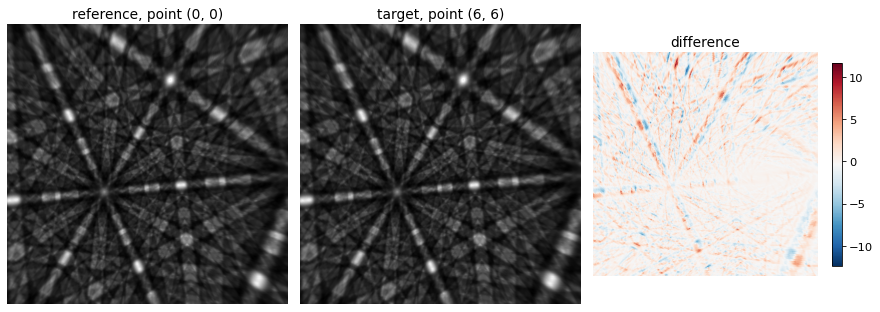

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
axes[0].imshow(s.data[0, 0], cmap="gray")
axes[0].set_title("reference, point (0, 0)")
axes[1].imshow(s.data[-1, -1], cmap="gray")
axes[1].set_title("target, point (6, 6)")
image = axes[2].imshow(s.data[-1, -1] - s.data[0, 0], cmap="RdBu_r")
axes[2].set_title("difference")
fig.colorbar(image, ax=axes[2], shrink=0.7)
for ax in axes:
    ax.axis("off")
fig.tight_layout()

The correlation needs a crystal map of the same navigation shape as the
signal.
Its orientations are used but never modified, and they are the
orientations of the map that comes back.

They enter the free functions in one place only, the rotation of the
elastic stiffness from the crystal frame to the sample frame, so a
strain and rotation run without a stiffness does not depend on them.
They enter the correlation itself in a second place that is easy to
miss: the default `reference="auto"` segments the map into grains from
the neighbour misorientation of these very orientations, and every
strain, rotation and density is then measured relative to the reference
pattern of the grain they define.
A map whose orientations are nominal must therefore name its reference
explicitly, which is what the next cell does.

In [6]:
arrays, n = create_coordinate_arrays(map_shape, (step_size, step_size))
arrays["rotations"] = Rotation(np.tile(orientation.data.ravel(), (n, 1)))
arrays["phase_id"] = np.zeros(n, dtype=int)
arrays["phase_list"] = PhaseList(Phase(name="ni", space_group=225))
xmap_in = CrystalMap(**arrays)
xmap_in.scan_unit = "um"
print(xmap_in)

Phase  Orientations  Name  Space group  Point group  Proper point group     Color
    0   49 (100.0%)    ni        Fm-3m         m-3m                 432  tab:blue
Properties: 
Scan unit: um


### Correlating

We know which pattern is undeformed here, so we name it directly with
`reference=(row, col)`, which makes one global reference for the whole
map.
The default `reference="auto"` instead segments the map into grains
with
[segment_grains()](../reference/generated/kikuchipy.indexing.segment_grains.rst)
and picks the pattern of highest image quality within each, which is
what the silicon section below uses.
An explicit array of one flat index per grain label is the third mode.

The knobs of the correlation, and the measured reasons for their
defaults:

* `filter_cutoffs=(0.05, None)` is a high-pass with no low-pass. It
  costs rotation capture range on noise free patterns, where an
  in-plane rotation of up to 2.0 degrees is recovered with it and up to
  4.0 degrees without it, and it is what makes real data work at all:
  on the silicon wafer below, 87 of 100 patterns converge with it
  against 1 of 100 without it.
* `border=0.05` keeps a frame of the pattern out of the correlated
  subregion, so that a beam scan translation does not walk the warped
  samples off the detector.
* `window=False`. A Hann window over the subregion is available and is
  off by default: switching it on takes convergence on that same wafer
  from 87 of 100 to 14 of 100.
* `max_iterations=50` and `min_step=1e-3` px, the convergence criterion
  being the largest displacement the increment warp induces over the
  four subregion corners.
* `upsample_factor=16` sets the precision of the phase
  cross-correlation that seeds every fit with a translation.

A point that reaches `max_iterations` keeps its last iterate with
`"converged"` set to `False` and gets NaN in every quantity derived
from it downstream.
It is never zeroed.

In [7]:
xmap = s.hrebsd_dic(xmap_in, detector, reference=(0, 0))

HREBSD-DIC information:
  Correlating 49 pattern(s) of shape (480, 480) against 1 reference(s)
  Chunking: 25 chunk(s) of up to 2 pattern(s)
  Estimated memory per reference: 22.0 MB
[                                        ] | 0% Completed | 780.00 us

[########                                ] | 21% Completed | 110.11 ms

[########                                ] | 21% Completed | 212.55 ms

[########                                ] | 21% Completed | 327.73 ms

[########                                ] | 21% Completed | 433.25 ms

...

[#################################       ] | 84% Completed | 1.63 s

[###################################     ] | 88% Completed | 1.73 s

[###################################     ] | 89% Completed | 1.83 s

[########################################] | 100% Completed | 1.94 s

  Correlation speed: 24.51736 patterns/s


In [8]:
print("properties:", sorted(xmap.prop.keys()))
print("converged:", int(xmap.prop["converged"].sum()), "of", xmap.size)
print("largest iteration count:", xmap.prop["num_iterations"].max())
print(f"median residual: {np.median(xmap.prop['residual']):.2e}")

properties: ['Fe', 'converged', 'grain_id', 'homography', 'norm_dp', 'num_iterations', 'reference_index', 'residual']
converged: 49 of 49
largest iteration count: 3
median residual: 2.79e-04


`"homography"` holds the eight raw fitted parameters, including the
rigid translation the beam scan induces, because that translation is
itself the signal the projection centre diagnostic reads.
`"Fe"` holds the reduced deformation gradient tensor of the detector
frame, row-major, with the beam scan phantom already removed from it.
Two dimensional properties are retrieved by reshaping rather than
through `CrystalMap.get_map_data()`, which is documented for scalar
properties:

In [9]:
fe_map = xmap.prop["Fe"].reshape(map_shape + (3, 3))
distortion = 1e3 * (fe_map[-1, -1] - np.eye(3))
print("Fe - I at point (6, 6), in units of 1e-3:")
print(np.round(distortion, 1) + 0.0)

Fe - I at point (6, 6), in units of 1e-3:
[[ 0.4  0.8  0.1]
 [-0.4  0.9  1. ]
 [-0.6  0.   0. ]]


## Strain, rotation and stress

[hrebsd_strain_stress()](../reference/generated/kikuchipy.indexing.hrebsd_strain_stress.rst)
carries each tensor from the detector frame to the sample frame, closes
the missing ninth degree of freedom, and splits the result by polar
decomposition $F = R\,U$ into a lattice rotation and an elastic strain.
The default strain measure is the Biot strain $U - I$, and
`strain_measure="green-lagrange"` gives $(U^\mathrm{T}U - I)/2$
instead.

Without a stiffness matrix the closure is *deviatoric*: the trace of
the distortion is set to zero.
Since we built the imposed field traceless, the deviatoric closure has
the exact answer to find, and we can compare component by component.

In [10]:
result = hrebsd_strain_stress(xmap, detector)
print("properties:", sorted(result.prop.keys()))

voigt = [(0, 0), (1, 1), (2, 2), (1, 2), (0, 2), (0, 1)]
expected_strain = np.zeros(map_shape + (6,))
expected_rotation = np.zeros(map_shape + (3,))
for row in range(map_shape[0]):
    for col in range(map_shape[1]):
        beta = imposed[row, col]
        symmetric = (beta + beta.T) / 2
        anti = (beta - beta.T) / 2
        expected_strain[row, col] = [symmetric[i, j] for i, j in voigt]
        expected_rotation[row, col] = [
            anti[2, 1],
            anti[0, 2],
            anti[1, 0],
        ]

strain = result.prop["strain"].reshape(map_shape + (6,))
rotation_vector = result.prop["rotation_vector"].reshape(map_shape + (3,))
worst_strain = np.abs(strain - expected_strain).max()
worst_rotation = np.abs(rotation_vector - expected_rotation).max()
print(f"worst strain component error: {worst_strain:.1e}")
print(f"worst rotation component error: {worst_rotation:.1e} rad")
print(f"imposed strain amplitude: {np.abs(expected_strain).max():.1e}")

properties: ['Fe', 'beta', 'converged', 'grain_id', 'homography', 'norm_dp', 'num_iterations', 'reference_index', 'residual', 'rotation_vector', 'strain', 'stress', 'stress_hydrostatic', 'stress_principal', 'stress_von_mises']
worst strain component error: 1.0e-05
worst rotation component error: 6.0e-06 rad
imposed strain amplitude: 8.3e-04


The whole chain, that is projection through the master pattern,
correlation, homography to tensor conversion, frame rotation, closure
and polar split, returns the imposed field to about one part in a
hundred of its own amplitude on noise free patterns.

The `"strain"` property is in Voigt order (11, 22, 33, 23, 13, 12) with
**tensor** shear components, not engineering ones.
The factor of two of the engineering convention lives only inside the
Hooke product.

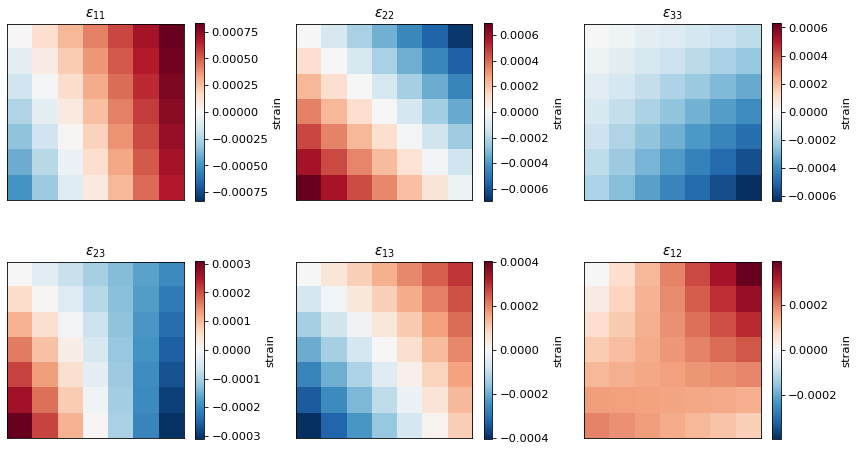

In [11]:
def plot_maps(
    maps, titles, cmap="viridis", label="", ncols=3, symmetric=False
):
    "Plot map shaped arrays side by side."
    nrows = int(np.ceil(len(maps) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.9 * ncols, 3.3 * nrows)
    )
    axes = np.ravel(axes)
    for ax, values, title in zip(axes, maps, titles):
        limit = float(np.nanmax(np.abs(values))) if symmetric else None
        image = ax.imshow(
            values,
            cmap=cmap,
            vmin=None if limit is None else -limit,
            vmax=limit,
        )
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(image, ax=ax, shrink=0.8, label=label)
    for ax in axes[len(maps) :]:
        ax.axis("off")
    fig.tight_layout()


plot_maps(
    [strain[..., i] for i in range(6)],
    [
        r"$\varepsilon_{11}$",
        r"$\varepsilon_{22}$",
        r"$\varepsilon_{33}$",
        r"$\varepsilon_{23}$",
        r"$\varepsilon_{13}$",
        r"$\varepsilon_{12}$",
    ],
    cmap="RdBu_r",
    label="strain",
    symmetric=True,
)

The lattice rotation comes back as a rotation vector in radians in the
sample frame, the rotation axis scaled by the rotation angle.
At the scale of HR-EBSD it is convenient in milliradians.

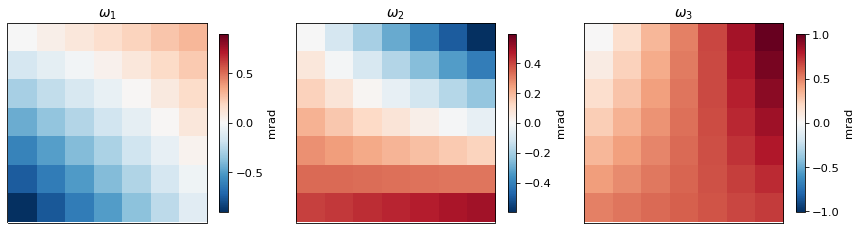

In [12]:
plot_maps(
    [1e3 * rotation_vector[..., i] for i in range(3)],
    [r"$\omega_1$", r"$\omega_2$", r"$\omega_3$"],
    cmap="RdBu_r",
    label="mrad",
    symmetric=True,
)

## Stress and the stiffness input

Stress needs elastic constants, and no elastic constant database ships
with kikuchipy or with any of its dependencies, so the stiffness is
supplied by the user, per phase.
The convention is stated in every docstring that touches it:

* a (6, 6) matrix in **GPa**,
* in the **crystal** frame,
* in Voigt order (11, 22, 33, 23, 13, 12),
* with the **engineering shear** convention in the Hooke product,
  $\sigma = C\,[\varepsilon_{11}, \varepsilon_{22}, \varepsilon_{33},
  2\varepsilon_{23}, 2\varepsilon_{13}, 2\varepsilon_{12}]$.

[voigt_stiffness()](../reference/generated/kikuchipy.indexing.voigt_stiffness.rst)
builds the matrix for cubic and hexagonal symmetry from the independent
constants.
It is rotated from the crystal frame to the sample frame internally, at
each point's own orientation, so a textured map is handled point by
point.

In [13]:
stiffness = voigt_stiffness("cubic", c11=246.5, c12=147.3, c44=124.7)
print(stiffness)

[[246.5 147.3 147.3   0.    0.    0. ]
 [147.3 246.5 147.3   0.    0.    0. ]
 [147.3 147.3 246.5   0.    0.    0. ]
 [  0.    0.    0.  124.7   0.    0. ]
 [  0.    0.    0.    0.  124.7   0. ]
 [  0.    0.    0.    0.    0.  124.7]]


With a stiffness given, the default `closure="auto"` switches from the
deviatoric closure to the **traction free** one: the surface normal
stress $\sigma_{33}$ is set to zero and the three normal strains are
solved for.
That is the standard HR-EBSD assumption for a free surface, and it is
the one that makes an absolute stress meaningful.

The two closures differ only in the unobservable isotropic part, so
every shear component and every difference of normal components is the
same under both.
Since we imposed a traceless field, the deviatoric closure recovers it
exactly while the traction free closure returns a different, and here
deliberately wrong, $\varepsilon_{33}$: our synthetic crystal is not a
traction free surface.
On real data it is the traction free number that one wants.

In [14]:
stressed = hrebsd_strain_stress(xmap, detector, stiffness=stiffness)
stress = stressed.prop["stress"].reshape(map_shape + (6,))
strain_tf = stressed.prop["strain"].reshape(map_shape + (6,))
print(f"largest |sigma_33|: {np.abs(stress[..., 2]).max():.2e} GPa")
print(f"stress amplitude: {np.abs(stress).max():.2e} GPa")
print(
    "largest shear strain difference between the closures: "
    f"{np.abs(strain_tf[..., 3:] - strain[..., 3:]).max():.1e}"
)
print(
    "largest e33 difference between the closures: "
    f"{np.abs(strain_tf[..., 2] - strain[..., 2]).max():.1e}"
)

largest |sigma_33|: 2.62e-04 GPa
stress amplitude: 1.97e-01 GPa
largest shear strain difference between the closures: 6.2e-11
largest e33 difference between the closures: 1.4e-04


$\sigma_{33}$ is zero by construction of the traction free closure
rather than by measurement, so it is stored beside the other five
components but carries no information of its own; its size is a self
check on the arithmetic, and here it is nearly three orders below the
stress amplitude, a factor of 752.

The derived stress maps are stored beside the tensor: the von Mises
equivalent stress, the hydrostatic stress and the three principal
stresses in descending order.
The hydrostatic stress deserves a caveat, since it is a product of the
closure assumption rather than of the measurement.

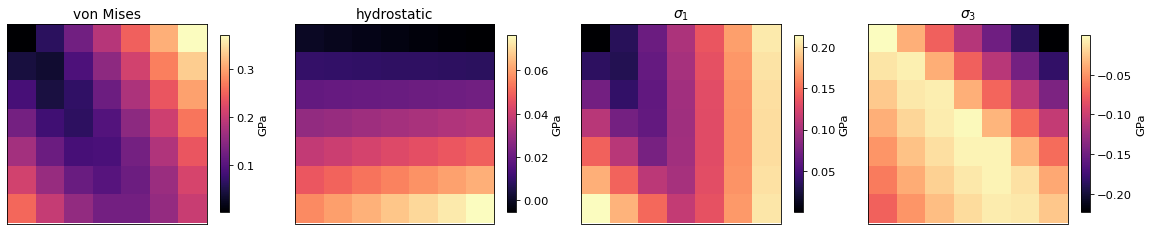

In [15]:
principal = stressed.prop["stress_principal"].reshape(map_shape + (3,))
plot_maps(
    [
        stressed.prop["stress_von_mises"].reshape(map_shape),
        stressed.prop["stress_hydrostatic"].reshape(map_shape),
        principal[..., 0],
        principal[..., 2],
    ],
    ["von Mises", "hydrostatic", r"$\sigma_1$", r"$\sigma_3$"],
    cmap="magma",
    label="GPa",
    ncols=4,
)

## HR-KAM and GND density

[hrebsd_kam()](../reference/generated/kikuchipy.indexing.hrebsd_kam.rst)
is the kernel average misorientation evaluated on the high resolution
rotation field rather than on the indexed orientations, so it is
reported in **milliradians** rather than in degrees: the HR-EBSD
rotation noise floor is two orders below the Hough one.
The default kernel is every point within a Chebyshev distance of one,
so the eight neighbours, and pairs are averaged only within a grain.
`psi_max` optionally drops pairs above a threshold, a guard against
sub-grain boundaries.

[hrebsd_gnd()](../reference/generated/kikuchipy.indexing.hrebsd_gnd.rst)
maps a scalar geometrically necessary dislocation density from the
in-plane gradients of the distortion field, that is the Nye tensor
$\alpha = \mathrm{curl}\,\beta$.
A surface map gives the three components $\alpha_{i3}$ exactly; the
other six follow only by neglecting the out-of-plane derivatives.
The three estimators consume different sets of them, with the L1
extrapolation prefactors of OpenXY:

* `"a3"` uses the three exact entries,
* `"a5"` (the default) adds $\alpha_{12}$ and $\alpha_{21}$,
* `"a9"` uses all nine.

The Burgers vector length is required, in metres, with no default, and
the map step sizes are read from the crystal map through its
`scan_unit`.
Both rules exist because silently guessing a unit is how prefactor
errors hide.

The noise reduction of
<cite data-cite="ruggles2020correlating">Ruggles et al. (2020)</cite>
is on by default: $\beta_{31}$ and $\beta_{32}$, the noisiest entries
of a detector frame measurement, are replaced by $-\beta_{13}$ and
$-\beta_{23}$ before the frame rotation, on the GND path only and never
on the stress path.
It is worth saying plainly what that does, because it is a trade and
not a filter.
Making the lower left of the detector frame tensor exactly minus its
upper right sets the two out of plane elastic shear strains
$\varepsilon_{13}$ and $\varepsilon_{23}$ of that frame to exactly
zero, so a measured elastic shear is given up in return for a quieter
noise operator.
`enforce_antisymmetry=False` turns it off, and since we know the field
we imposed we can price the trade rather than assume it.

In [16]:
burgers_ni = 2.49e-10  # m, a/2<110> at a = 3.524 A

kam = hrebsd_kam(result)
gnd = hrebsd_gnd(xmap, detector, burgers_ni)
print(f"median HR-KAM: {np.nanmedian(kam):.2f} mrad")
for estimator in ("a3", "a5", "a9"):
    density = hrebsd_gnd(xmap, detector, burgers_ni, estimator=estimator)
    print(f"{estimator}: {np.nanmedian(density):.2e} m^-2")

# The same public function on the tensors we IMPOSED, so the recovered
# density is checked against an answer known by construction
xmap_imposed = xmap.deepcopy()
xmap_imposed.prop["Fe"] = imposed_fe.reshape(-1, 9)
for label, fix in (("no fix", False), ("with the fix", True)):
    density = hrebsd_gnd(
        xmap_imposed, detector, burgers_ni, enforce_antisymmetry=fix
    )
    print(f"imposed field, {label}: {np.nanmedian(density):.2e} m^-2")
print(f"recovered from the patterns: {np.nanmedian(gnd):.2e} m^-2")

median HR-KAM: 0.19 mrad
a3: 2.21e+12 m^-2
a5: 2.41e+12 m^-2
a9: 2.65e+12 m^-2
imposed field, no fix: 2.22e+12 m^-2
imposed field, with the fix: 2.40e+12 m^-2
recovered from the patterns: 2.41e+12 m^-2


The recovered density lands on the *fixed* field and not on the
imposed one.
The eight per cent between the two is the price of the antisymmetry
fix rather than a correlation error: the strain comparison further up
put the whole chain's error at about one part in a hundred of the
imposed amplitude, and these two densities agree to better than that.
So the fix is a choice to make on noisy data, where the $\beta_{31}$
and $\beta_{32}$ noise it removes is real, and a known bias on clean
data.

The three estimators differ, as they must: they sum different numbers
of terms with different prefactors.
None of them is a measurement of a dislocation *content*.
They are lower bound estimates of a density under an assumption about
the out-of-plane derivatives, and the per slip system split that would
resolve dislocation types is not part of this release.

Density maps are read on a base ten logarithmic scale, and the
logarithm needs a guard: a density is a sum of moduli and so is never
negative, but it is exactly zero on a curvature free map, where a bare
`np.log10` warns and returns `-inf`.

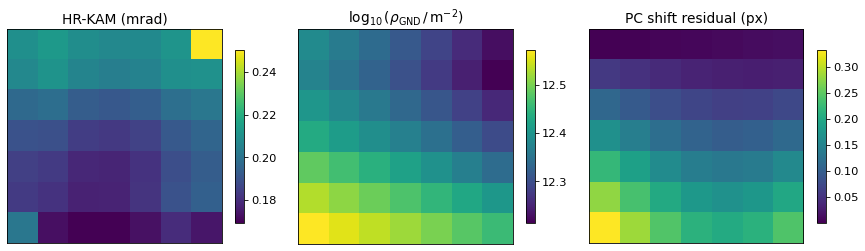

In [17]:
shift = hrebsd_pc_shift(xmap, detector)
residual = np.hypot(shift["residual_x"], shift["residual_y"])
plot_maps(
    [kam, np.log10(np.where(gnd > 0, gnd, np.nan)), residual],
    [
        "HR-KAM (mrad)",
        r"$\log_{10}(\rho_\mathrm{GND}\,/\,\mathrm{m}^{-2})$",
        "PC shift residual (px)",
    ],
    cmap="viridis",
)

The third map needs a word, because on this data set it is not quite
what its name suggests.
[hrebsd_pc_shift()](../reference/generated/kikuchipy.indexing.hrebsd_pc_shift.rst)
returns the translation each fit measured, the translation the beam
scan geometry predicts from the per-point projection centres, and the
difference between them.
A nonzero *mean* of that difference over a strain free region is the
signature of a miscalibrated projection centre
(<cite data-cite="ruggles2020correlating">Ruggles et al., 2020</cite>).
Here the modelled shift is 0.17 pixel across the whole map, the scan
step being 2 um against a 70 um detector pixel, while the measured
translation is dominated by the out-of-plane tilt of the imposed field,
which enters the homography translation as $F_{e,13}\,\mathrm{DD}$.
So on this map the residual is mostly real lattice signal, which is why
the diagnostic is read on a region known to be undeformed.
The silicon wafer below is such a region, and there the modelled shift
is 20 pixels.

The documented refinement workflow, which this release deliberately
does not automate, is to fit a plane to `"residual_x"` and
`"residual_y"` over a strain free region and feed it back through
[EBSDDetector.fit_pc()](../reference/generated/kikuchipy.detectors.EBSDDetector.fit_pc.rst).

In [18]:
print(sorted(shift.keys()))
for key in ("translation_x", "translation_x_model", "residual_x"):
    values = shift[key]
    print(f"{key}: {np.nanmin(values):.3f} to {np.nanmax(values):.3f} px")

['residual_x', 'residual_y', 'scaling_model', 'translation_x', 'translation_x_model', 'translation_y', 'translation_y_model']
translation_x: -0.169 to 0.333 px
translation_x_model: -0.171 to 0.000 px
residual_x: -0.000 to 0.333 px


## The noise floor on a strain free silicon wafer

Synthetic patterns say what the implementation does; they say nothing
about noise, detector distortion or pattern quality.
The one measurement that does is a nominally strain free single
crystal: whatever it reports is a floor, the true answer being zero.

We use the (50, 50) silicon wafer scan of (480, 480) patterns that
kikuchipy ships for projection centre calibration, on every fifth point
of both axes, so 100 patterns at a 200 um step.
The data set is about 311 MB and is downloaded once.

In [19]:
s_si = kp.data.si_wafer(allow_download=True, lazy=True)
s_si = s_si.inav[::5, ::5]
s_si.compute(show_progressbar=False)
print(s_si)

<EBSD, title: Pattern, dimensions: (10, 10|480, 480)>


Background removal is the user's choice and is never implied by the
correlation.
The engine applies its own band-pass inside the fitting loop, to the
reference and to every target alike, and that is a different step from
kikuchipy's
[remove_static_background()](../reference/generated/kikuchipy.signals.EBSD.remove_static_background.rst)
and
[remove_dynamic_background()](../reference/generated/kikuchipy.signals.EBSD.remove_dynamic_background.rst),
which act on the patterns before they ever reach it.
Here is what they do to this wafer.
The correlation below runs on the *raw* patterns, for a reason the
honesty section at the end of this notebook gives.

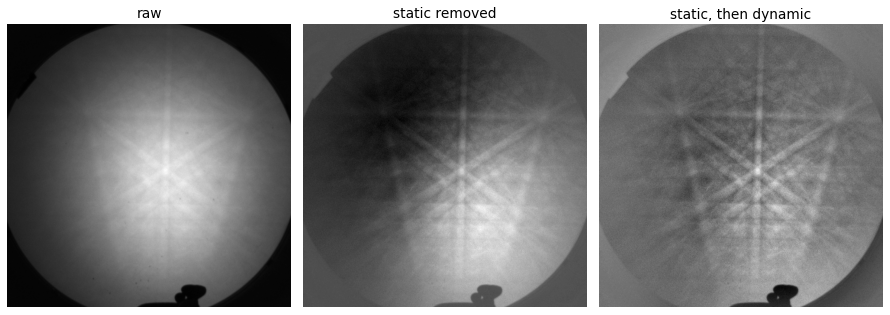

In [20]:
s_raw = s_si.inav[:2, :2].deepcopy()
s_static = s_raw.deepcopy()
s_static.remove_static_background(show_progressbar=False)
s_dynamic = s_static.deepcopy()
s_dynamic.remove_dynamic_background(show_progressbar=False)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, signal, title in zip(
    axes,
    (s_raw, s_static, s_dynamic),
    ("raw", "static removed", "static, then dynamic"),
):
    ax.imshow(signal.data[0, 0], cmap="gray")
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()

The detector needs two corrections before it can be used, and both are
the caller's job rather than the engine's.

The shipped detector carries the placeholder `px_size = 1.0` beside a
40 um scan step.
The beam scan model divides every step by `px_size * binning`, so with
the placeholder it would put the projection centre 1800 pixels across a
480 pixel detector.
The NORDIF UF-420 pixel size for this very data set is about 90 um, the
number kikuchipy's own [projection centre fitting
tutorial](pc_fit_plane.ipynb) uses.
The projection centre itself stays at the shipped value: substituting
the Hough refined one from that tutorial moves the strain floor
reported below by 2.4 per cent.

A nominal orientation is enough here, but for a different reason than
the synthetic section could rely on.
This run keeps the default `reference="auto"`, so the orientations do
reach the measurement through the grain segmentation; a single crystal
is however one grain under any constant orientation field, so the
segmentation returns the same single label whatever constant it is
given.
The deviatoric closure of the default route then needs no stiffness to
rotate.
On a real multigrain map neither would hold, and the orientations would
have to be the indexed ones.

In [21]:
step_si = (200.0, 200.0)  # um, every fifth point of a 40 um scan

detector_si = s_si.detector.deepcopy()
detector_si.px_size = 90.0
detector_si = detector_si.extrapolate_pc(
    pc_indices=[0, 0],
    navigation_shape=s_si.axes_manager.navigation_shape[::-1],
    step_sizes=step_si,
)
drift_si = 480 * (detector_si.pc[-1, -1, :2] - detector_si.pc[0, 0, :2])
print("modelled PC drift across the map (px):", np.round(drift_si, 2))

arrays, n_si = create_coordinate_arrays((10, 10), step_si)
arrays["rotations"] = Rotation.identity((n_si,))
arrays["phase_id"] = np.zeros(n_si, dtype=int)
arrays["phase_list"] = PhaseList(Phase(name="si", space_group=227))
xmap_si_in = CrystalMap(**arrays)
xmap_si_in.scan_unit = "um"
print(xmap_si_in)

modelled PC drift across the map (px): [-20.   -18.79]
Phase  Orientations  Name  Space group  Point group  Proper point group     Color
    0  100 (100.0%)    si        Fd-3m         m-3m                 432  tab:blue
Properties: 
Scan unit: um


This run uses the default `reference="auto"`, which segments the map
into grains and picks the highest image quality pattern of each.
A single crystal is one grain, so one pattern serves the whole map.

In [22]:
# verbose=0 keeps the progress bar of this longer run out of the
# stored output
xmap_si = s_si.hrebsd_dic(xmap_si_in, detector_si, verbose=0)

C:\Users\westraadt.1\Repos\kikuchipy\src\kikuchipy\indexing\_hrebsd\_engine.py:1028: UserWarning: 13 of 100 pattern(s) did not converge or failed, and carry their last iterate with `converged=False` and NaN in every derived property; they are never zeroed
  warnings.warn(


In [23]:
result_si = hrebsd_strain_stress(xmap_si, detector_si)
strain_si = np.asarray(result_si.prop["strain"])
rotation_si = np.asarray(result_si.prop["rotation_vector"])
finite = np.all(np.isfinite(strain_si), axis=1)
kam_si = hrebsd_kam(result_si)
gnd_si = hrebsd_gnd(xmap_si, detector_si, 3.84e-10)
shift_si = hrebsd_pc_shift(xmap_si, detector_si)

print("converged:", int(xmap_si.prop["converged"].sum()), "of 100")
print("grain labels:", np.unique(xmap_si.prop["grain_id"]))
print("strain floor: " f"{np.nanmax(np.std(strain_si[finite], axis=0)):.2e}")
print(
    "rotation floor: "
    f"{np.nanmax(np.std(rotation_si[finite], axis=0)):.2e} rad"
)
print(f"median HR-KAM: {np.nanmedian(kam_si):.2f} mrad")
print(
    f"median GND density: {np.nanmedian(gnd_si):.2e} m^-2, over "
    f"{int(np.isfinite(gnd_si).sum())} finite points"
)
print(
    "mean PC shift residual: "
    f"{np.nanmean(shift_si['residual_x']):.2f} and "
    f"{np.nanmean(shift_si['residual_y']):.2f} px, against a modelled "
    f"drift of {abs(drift_si[0]):.1f} px"
)

converged: 87 of 100
grain labels: [0]
strain floor: 1.22e-02
rotation floor: 1.20e-02 rad
median HR-KAM: 5.24 mrad
median GND density: 1.12e+11 m^-2, over 66 finite points
mean PC shift residual: 11.00 and 9.84 px, against a modelled drift of 20.0 px


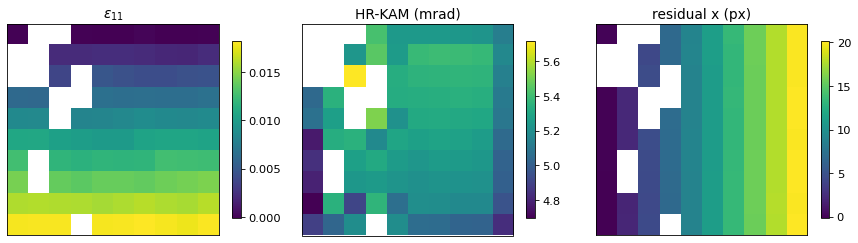

In [24]:
plot_maps(
    [
        strain_si[:, 0].reshape(10, 10),
        kam_si,
        shift_si["residual_x"],
    ],
    [r"$\varepsilon_{11}$", "HR-KAM (mrad)", "residual x (px)"],
    cmap="viridis",
)

One more map comes from existing kikuchipy functionality rather than
from this feature.
[get_image_quality()](../reference/generated/kikuchipy.signals.EBSD.get_image_quality.rst)
is the score `reference="auto"` ranks the candidates of each grain by,
so on this single grain the reference is the map's own image quality
maximum, and its flat index is what `"reference_index"` stores.

reference index: 0
image quality maximum at: 0


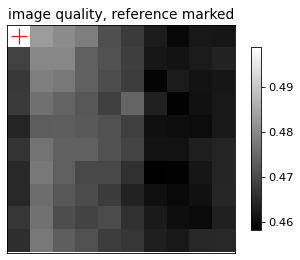

In [25]:
iq_si = s_si.get_image_quality(show_progressbar=False)
reference_index = int(xmap_si.prop["reference_index"][0])
print("reference index:", reference_index)
print("image quality maximum at:", int(np.argmax(iq_si)))

fig, ax = plt.subplots(figsize=(4.6, 3.6))
image = ax.imshow(iq_si, cmap="gray")
ax.plot(reference_index % 10, reference_index // 10, "r+", ms=16)
ax.set_title("image quality, reference marked")
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(image, ax=ax, shrink=0.8)
fig.tight_layout()

### What this data set can and cannot support

The strain floor above is about 1.2e-02.
The literature class for IC-GN homography HR-EBSD at this pattern size
is 1e-4 to 2e-4
(<cite data-cite="wilkinson2006high">Wilkinson et al., 2006</cite>;
<cite data-cite="ruggles2018new">Ruggles et al., 2018</cite>), so the
number is two orders out, and quoting it as this implementation's
precision without saying why would be dishonest.
Three measurements separate the engine from the data.

* **The engine is not at fault.** Warping a real wafer pattern by a
  known homography and refitting it recovers the homography to 0.033
  pixel of corner displacement, against 0.007 pixel on a noise free
  synthetic reference, and every case converges.
* **The pattern pairs are.** Two *different* wafer patterns,
  band-passed at the default cut-offs, correlate at a normalized
  cross-correlation of 0.84 when adjacent and 0.75 at opposite corners
  of the block, while a synthetic warp of one pattern against itself
  stays at 0.98. `phase_cross_correlation` returns 0.0 pixel for seven
  of the eight pairs tested and -0.06 pixel for the eighth, and the
  fits measure a median translation of 0.045 pixel where the beam scan
  model puts 20 pixels. A component that survives the high-pass and
  does not move with the beam is pinning the correlation at zero shift.
* **Subtracting the map average is not the remedy**, because on a
  single crystal scan the map average *is* the Kikuchi pattern:
  removing it takes convergence from 87 of 100 to 11 of 100. That is
  why the run above uses the raw patterns and not the background
  removed ones shown earlier.

The reason lies in the provenance of the data.
The wafer scan was acquired for projection centre calibration, which
reads band *positions* and is untroubled by a fixed pattern component.
HR-EBSD reads band *shapes* and is not.
So the numbers above are this data set's floors and not the method's.

The same caution applies to the GND floor.
A median of about 1.1e11 m$^{-2}$ looks far below the 4e12 to
8e12 m$^{-2}$ literature class, and reading that as a better floor
would be exactly backwards: that class is quoted at a 100 nm step while
this sub-grid's step is 200 um, two thousand times longer, and a
curvature is a distortion divided by a distance.
Put this data set's own rotation floor into the same relation,
$\rho \sim \sigma_\beta / (b\,\Delta x)$, and it predicts
1.6e11 m$^{-2}$, so the measured floor is consistent with being noise
and nothing else.

The antisymmetry fix does not help here either, and it is worth
recording that it does not.
On this data set it *raises* the GND floor by 44 per cent, 1.1e11
against 7.8e10 m$^{-2}$ without it, which is the opposite of the
direction its noise argument describes.
That argument is about $\beta_{31}$ and $\beta_{32}$ noise, and this
map's floor is set by the fixed pattern component diagnosed above
instead, so the argument simply does not apply to it.
The default is kept on the geometry, not on this measurement.

The GND map is also sparser than the convergence count alone suggests.
A central difference stencil that touches a non-converged point yields
NaN rather than a fabricated number, so the 13 failures of this map
take their in-plane neighbours with them and 66 of 100 points survive.
A data set acquired for HR-EBSD, with a fine step across a deformed
region, is where a method level floor can be measured.

## Limitations of this release

* **No optical or radial distortion correction.** Lens coupled
  detectors distort the pattern, and the correction belongs inside the
  DIC loop
  (<cite data-cite="ernould2021integrated">Ernould et al.,
  2021</cite>).
  It is not implemented here, which matters for strains in the 1e-4 to
  2e-3 band on lens coupled detectors and much less on fibre coupled or
  direct detectors.
* **Relative only.** Every quantity is measured against a real,
  measured reference pattern of the same grain, so absolute strain and
  cross-grain comparison are out of reach, and the strain of a
  reference point is zero by definition rather than by measurement.
  Measurement against a simulated reference is not offered.
* **Single phase stress.** The stress path requires a single phase
  crystal map, one stiffness matrix being supplied per call. The
  correlation engine itself is phase agnostic, and a multiphase map is
  segmented per phase.
* **A finite rotation capture range.** The initial guess is a
  translation only phase cross-correlation, so a large in-plane
  rotation between reference and target is not recovered: 2.0 degrees
  at 480 pixels with the default band-pass, 4.0 degrees with none. A
  Fourier-Mellin pre-rotation stage would lift it and is not built.
* **Precision scales with pattern size.** The published IC-GN
  homography figure is a strain of about 8e-5 at 960 by 960 pixels. The
  60 by 60 pixel data sets shipped with kikuchipy sit one to two orders
  above that and are for demonstration and testing only, so every
  precision claim here is tied to 480 by 480 pixels or larger.
* **Scalar GND only.** The per slip system L1 split that resolves
  dislocation types, and the Burgers vector maps that come with it, are
  not implemented. Neither is a tetragonality map.
* **Projection centre feedback is manual.** The residual maps are a
  diagnostic; no automatic refinement loop closes over them.

## References

The conventions of this implementation are re-derived from the
published equations and pinned by synthetic oracles rather than taken
from another implementation.
The literature it rests on:

* <cite data-cite="wilkinson2006high">Wilkinson, Meaden and Dingley
  (2006)</cite>, the cross-correlation HR-EBSD original.
* <cite data-cite="villert2009accuracy">Villert, Maurice, Wyon and
  Fortunier (2009)</cite>, on the accuracy of EBSD strain measurement
  and the role of the projection centre.
* <cite data-cite="ruggles2018new">Ruggles, Bomarito, Qiu and
  Hochhalter (2018)</cite>, inverse compositional Gauss-Newton digital
  image correlation for HR-EBSD.
* <cite data-cite="ernould2020global">Ernould, Beausir, Fundenberger,
  Taupin and Bouzy (2020)</cite>, the global homography approach with a
  cross-correlation guided initial guess, and
  <cite data-cite="ernould2021integrated">Ernould et al.
  (2021)</cite>, its integrated optical distortion correction.
* <cite data-cite="pantleon2008resolving">Pantleon (2008)</cite> and
  <cite data-cite="ruggles2020correlating">Ruggles et al.
  (2020)</cite>, on which components of the Nye tensor a surface map
  gives and on keeping their noise down.
* <cite data-cite="jiang2013measurement">Jiang, Britton and Wilkinson
  (2013)</cite>, on the GND noise floor and its dependence on step size
  and detector binning.

Two other open source implementations served as equation level cross
references while this was written, and neither is ported here:
[OpenXY](https://github.com/BYU-MicrostructureOfMaterials/OpenXY) and
the HR-EBSD module of
[ATEX](http://www.atex-software.eu/hrebsd.html).